<a href="https://colab.research.google.com/github/phaneendra-simhadri/phaneendra_ML/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A2 & A3: Encoding Categorical Features
Label encoding for 'Education': {'Graduation': 0, 'PhD': 1, 'Master': 2, 'Basic': 3, '2n Cycle': 4}

Dataset shape after encoding: (2240, 36)
Columns after encoding: ['ID', 'Year_Birth', 'Education', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd', 'YOLO']
First few rows after encoding:
     ID  Year_Birth  Education   Income  Kidhome  Teenhome  \
0  5524        1957          0  58138.0        0         0   
1  2174        1954          0  46344.0        1         1   
2  4141        1965          0  71613.0        0         0   
3  6

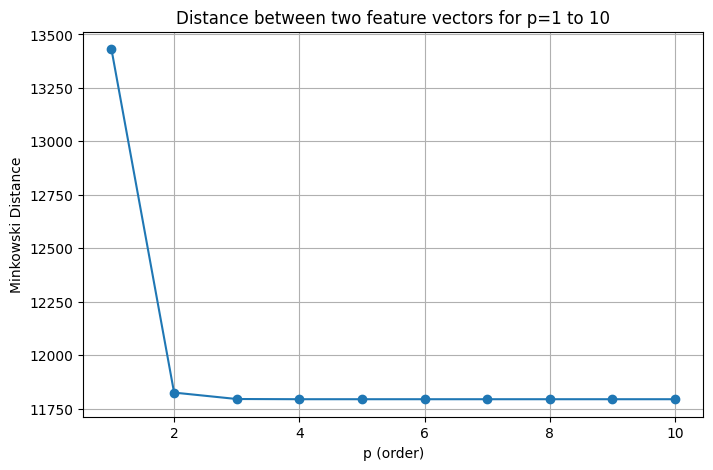

A6: Compare our function with scipy's implementation
p=1: Our distance = 13431.000000, Scipy distance = 13431.000000, diff = 0.00e+00
p=2: Our distance = 11825.004228, Scipy distance = 11825.004228, diff = 0.00e+00
p=3: Our distance = 11794.975787, Scipy distance = 11794.975787, diff = 0.00e+00
A7: Dot product and Euclidean norm
Dot product of the two vectors: 2698185161.0000
Euclidean norm of vector 1: 58177.4422
Euclidean norm of vector 2: 46385.1944
A8 & A9: Column-wise statistics (mean, variance, std)
Comparison (first 5 features):
Feature 1:
  Our mean = 1968.8058, numpy mean = 1968.8058
  Our var  = 143.5538, numpy var  = 143.5538
  Our std  = 11.9814, numpy std  = 11.9814
Feature 2:
  Our mean = 0.9821, numpy mean = 0.9821
  Our var  = 1.5800, numpy var  = 1.5800
  Our std  = 1.2570, numpy std  = 1.2570
Feature 3:
  Our mean = nan, numpy mean = nan
  Our var  = nan, numpy var  = nan
  Our std  = nan, numpy std  = nan
Feature 4:
  Our mean = 0.4442, numpy mean = 0.4442
  Our var 

In [15]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import minkowski as scipy_minkowski


def label_encode(column):
    unique_values = column.unique()
    mapping = {}

    for i, value in enumerate(unique_values):
        mapping[value] = i

    encoded = column.map(mapping)
    return encoded, mapping



# One-Hot Encoding Function

def one_hot_encode(column):
    unique_values = column.unique()

    encoded_df = pd.DataFrame()

    for value in unique_values:
        encoded_df[value] = (column == value).astype(int)

    return encoded_df

# A4: Minkowski distance
def minkowski_distance(vec1, vec2, p):

    vec1 = np.array(vec1, dtype=float)
    vec2 = np.array(vec2, dtype=float)
    return np.sum(np.abs(vec1 - vec2) ** p) ** (1.0 / p)

# A7: Dot product
def dot_product(vec1, vec2):

    vec1 = np.array(vec1, dtype=float)
    vec2 = np.array(vec2, dtype=float)
    return np.dot(vec1, vec2)

# A7: Euclidean
def eculidean(vec):
    vec = np.array(vec, dtype=float)
    return np.sqrt(np.sum(vec ** 2))

# A8: Mean, variance, standard deviation
def mean(data):
    data = np.array(data, dtype=float)
    return np.sum(data) / len(data)

def variance(data):
    data = np.array(data, dtype=float)
    mu = mean(data)
    return np.sum((data - mu) ** 2) / len(data)

def std_dev(data):
    return np.sqrt(variance(data))

#A8: column wise...
def column_stats(matrix):
    matrix = np.array(matrix, dtype=float)
    n_cols = matrix.shape[1]
    means = np.array([mean(matrix[:, col]) for col in range(n_cols)])
    variances = np.array([variance(matrix[:, col]) for col in range(n_cols)])
    stds = np.array([std_dev(matrix[:, col]) for col in range(n_cols)])
    return means, variances, stds



if __name__ == "__main__":


    # Load the dataset

    df = pd.read_excel("/content/Lab Session Data.xlsx", sheet_name="marketing_campaign")

    # A2 & A3: Label Encoding and One-Hot Encoding
    print("A2 & A3: Encoding Categorical Features")

    # Apply Label Encoding to 'Education'
    df['Education'], edu_mapping = label_encode(df['Education'])
    print("Label encoding for 'Education':", edu_mapping)

    # Apply One-Hot Encoding to 'Marital_Status'
    marital_encoded = one_hot_encode(df['Marital_Status'])
    # Drop original column and concatenate the encoded ones
    df = df.drop('Marital_Status', axis=1)
    df = pd.concat([df, marital_encoded], axis=1)

    print("\nDataset shape after encoding:", df.shape)
    print("Columns after encoding:", list(df.columns))
    print("First few rows after encoding:")
    print(df.head())

    # A4 & A5: Minkowski distance with p from 1 to 10
    print("A4 & A5: Minkowski Distance for two vectors (p=1..10)")

    # I used all numeric columns (skip ID and dates if present)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # Remove 'ID' and 'Dt_Customer' if present (they are not meaningful for distance)
    if 'ID' in numeric_cols:
        numeric_cols.remove('ID')
    if 'Dt_Customer' in numeric_cols:
        numeric_cols.remove('Dt_Customer')

    data_matrix = df[numeric_cols].values
    vec1 = data_matrix[0]
    vec2 = data_matrix[1]

    distances = []
    p_values = range(1, 11)
    for p in p_values:
        d = minkowski_distance(vec1, vec2, p)
        distances.append(d)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(p_values, distances, marker='o', linestyle='-')
    plt.xlabel('p (order)')
    plt.ylabel('Minkowski Distance')
    plt.title('Distance between two feature vectors for p=1 to 10')
    plt.grid(True)
    plt.show()

    # A6: Compare with scipy.spatial.distance.minkowski
    print("A6: Compare our function with scipy's implementation")
    print("=" * 60)
    for p in [1, 2, 3]:
        my_dist = minkowski_distance(vec1, vec2, p)
        scipy_dist = scipy_minkowski(vec1, vec2, p)
        print(f"p={p}: Our distance = {my_dist:.6f}, Scipy distance = {scipy_dist:.6f}, diff = {abs(my_dist - scipy_dist):.2e}")

    # A7: Dot product and Euclidean norm
    print("A7: Dot product and Euclidean norm")
    dp = dot_product(vec1, vec2)
    norm1 = eculidean(vec1)
    norm2 = eculidean(vec2)
    print(f"Dot product of the two vectors: {dp:.4f}")
    print(f"Euclidean norm of vector 1: {norm1:.4f}")
    print(f"Euclidean norm of vector 2: {norm2:.4f}")

    # A8 & A9: Mean, variance, std (our functions vs numpy)
    print("A8 & A9: Column-wise statistics (mean, variance, std)")

    mat = data_matrix  # already numeric
    my_means, my_vars, my_stds = column_stats(mat)

    # Using numpy functions
    np_means = np.mean(mat, axis=0)
    np_vars = np.var(mat, axis=0)
    np_stds = np.std(mat, axis=0)

    print("Comparison (first 5 features):")
    for i in range(min(5, mat.shape[1])):
        print(f"Feature {i+1}:")
        print(f"  Our mean = {my_means[i]:.4f}, numpy mean = {np_means[i]:.4f}")
        print(f"  Our var  = {my_vars[i]:.4f}, numpy var  = {np_vars[i]:.4f}")
        print(f"  Our std  = {my_stds[i]:.4f}, numpy std  = {np_stds[i]:.4f}")



In [ ]:
def kmeans(data, k):
    data = np.array(data, dtype=float)
    n = len(data)

    # Step 1: Pick K random points as centroids
    centroids = data[np.random.choice(n, k, replace=False)]

    while True:
        # Step 2: Assign each point to closest centroid
        labels = []
        for point in data:
            dists = []
            for c in centroids:
                dists.append(minkowski_distance(point, c, 2))
            labels.append(np.argmin(dists))
        labels = np.array(labels)

        # Step 3: Recompute centroids
        new_centroids = []
        for j in range(k):
            cluster = data[labels == j]
            if len(cluster) > 0:
                new_centroids.append(np.mean(cluster, axis=0))
            else:
                new_centroids.append(data[np.random.choice(n)])
        new_centroids = np.array(new_centroids)

        # Step 4: Check if centroids changed
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids

    return centroids, labels